## Introducción a la Segmentación de Clientes con Datos Reales

Imagine que tiene un conjunto de datos de clientes y necesita aplicar la segmentación de clientes sobre estos datos históricos.

La segmentación de clientes es la práctica de dividir una base de clientes en grupos de individuos que tienen características similares. Es una estrategia significativa, ya que una empresa puede dirigirse a estos grupos específicos de clientes y asignar efectivamente recursos de marketing. Por ejemplo, un grupo puede contener clientes que tienen una alta ganancia y bajo riesgo, es decir, más propensos a comprar productos o suscribirse a un servicio. Una tarea de negocio es retener a esos clientes. Otro grupo podría incluir clientes de organizaciones sin fines de lucro y así sucesivamente.

## 1. Carga y Configuración del Dataset

Para este proyecto utilizaremos un conjunto de datos histórico de clientes alojado en la nube. Este archivo CSV contiene información demográfica y de comportamiento transaccional que nos permitirá aplicar el algoritmo K-Means en un escenario del mundo real.

In [2]:
import pandas as pd

# Definimos la ruta del archivo CSV
path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%204/data/Cust_Segmentation.csv'

# Cargamos el dataset utilizando Pandas
df = pd.read_csv(path)

# Mostramos las primeras filas para verificar que se cargó correctamente
df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2


In [3]:
# Renombramos las columnas principales al español para mayor comodidad
df = df.rename(columns={
    'Customer Id': 'Id_Cliente',
    'Age': 'Edad',
    'Edu': 'Nivel_Educativo',
    'Years Employed': 'Años_Empleo',
    'Income': 'Ingresos',
    'Card Debt': 'Deuda_Tarjeta',
    'Other Debt': 'Otra_Deuda',
    'Defaulted': 'Incumplimiento',
    'DebtIncomeRatio': 'Ratio_Deuda_Ingreso'
})

# Verificamos los cambios mostrando las primeras filas ya traducidas
df.head()

,Id_Cliente,Edad,Nivel_Educativo,Años_Empleo,Ingresos,Deuda_Tarjeta,Otra_Deuda,Incumplimiento,Address,Ratio_Deuda_Ingreso
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2


## 2. Preprocesamiento de Datos

Antes de aplicar K-Means en un entorno real, debemos preparar el dataset:
1. **Eliminar columnas no numéricas o irrelevantes:** Columnas como la dirección (`Address`) o identificadores únicos no aportan información matemática para calcular distancias geométricas, por lo que deben descartarse para el clustering.
2. **Manejo de valores nulos:** Asegurarnos de que no existan datos vacíos que puedan romper los cálculos del algoritmo.
3. **Normalización (Escalado):** Como las variables tienen escalas muy diferentes (por ejemplo, la edad va de 18 a 100 y los ingresos van por miles), utilizaremos `StandardScaler` para que todas tengan el mismo peso estadístico.

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Guardamos los IDs de los clientes en una variable independiente antes de entrenar
# (Manejamos por si el nombre de la columna está en español o en su versión original en inglés)
id_columna = 'Id_Cliente' if 'Id_Cliente' in df.columns else 'Customer Id'
customer_ids = df[id_columna].copy()

# 2. Creamos el dataset para clustering eliminando columnas no numéricas (Address y el ID)
df_cluster = df.drop(['Address', id_columna], axis=1, errors='ignore')

# 3. Eliminamos filas con valores nulos (NaN) 
# Nota: Si removemos filas con nulos, debemos asegurarnos de que los IDs coincidan exactamente,
# por lo que es mejor filtrar ambos usando el mismo índice resultante de dropna().
df_cluster = df_cluster.dropna()
customer_ids = customer_ids.loc[df_cluster.index]

# 4. Normalizamos/escalamos los datos numéricos
X = df_cluster.values
X = np.nan_to_num(X)

Clasificador = StandardScaler()
X_scaled = Clasificador.fit_transform(X)

print(f"Datos listos. Total de clientes procesados: {len(X_scaled)}")

Datos listos. Total de clientes procesados: 700


id_columna = ... y customer_ids = ...: Detecta automáticamente si tu columna de identificación se llama Id_Cliente o Customer Id y la guarda en una variable independiente para no perderla de vista.

df_cluster = df.drop(...): Remueve la columna de dirección (Address) porque es texto libre y elimina el ID del conjunto de datos de entrenamiento (con errors='ignore' por si alguna ya fue borrada).

df_cluster = df.dropna(): Elimina todas las filas que contengan algún valor vacío (NaN), ya que las matemáticas de K-Means no funcionan con datos faltantes.

customer_ids = customer_ids.loc[df_cluster.index]: Asegura que los IDs se recorten exactamente igual que el DataFrame para que mantengan la misma posición y orden de las filas.

X = df_cluster.values: Extrae únicamente los números del DataFrame de Pandas y los convierte en una matriz de NumPy, que es el formato que exige Scikit-Learn.

X = np.nan_to_num(X): Una medida de seguridad adicional que reemplaza cualquier valor numérico extremo o inválido por ceros.

Clasificador = StandardScaler(): Inicializa el objeto encargado de normalizar las variables (centrarlas y ponerlas en una misma escala).

X_scaled = Clasificador.fit_transform(X): Aplica la fórmula matemática para escalar todos los datos numéricos y deja la matriz lista para el modelo.

In [6]:
X_scaled

array([[ 0.76830405,  0.29879269, -0.35900652, ..., -0.60428433,
        -0.59494973, -0.58052847],
       [ 1.51908977, -0.77932527,  2.64702891, ...,  1.5706204 ,
        -0.59494973,  0.37222169],
       [-0.23274357,  0.29879269,  0.24220057, ...,  0.83520125,
         1.68081427,  1.55949495],
       ...,
       [-1.2337912 ,  2.45502862, -1.26081715, ...,  0.04620852,
         1.68081427,  3.39170678],
       [-0.35787453, -0.77932527,  0.54280411, ..., -0.71904138,
        -0.59494973, -1.07889008],
       [ 2.14474454, -0.77932527,  1.1440112 , ...,  0.17648972,
        -0.59494973, -0.24340149]], shape=(700, 8))

El resultado que ves en la imagen es una matriz numérica transformada (escalada) de tipo array de NumPy, que es exactamente lo que debe arrojar el StandardScaler.

Aquí te explico punto por punto qué significan esos números y por qué se ven así:

¿Por qué son puros decimales negativos y positivos?
Al aplicar el StandardScaler, cada columna de tu dataset original (como la edad, los ingresos, las deudas, etc.) fue ajustada mediante una fórmula matemática para que:

Su promedio (media) sea exactamente igual a 0.

Su desviación estándar sea igual a 1.

¿Qué significa que un número sea positivo o negativo?

Un número positivo (ej. +1.48 o +2.11) significa que ese cliente específico está por encima del promedio general de la base de datos en esa característica (por ejemplo, gana más que la media, o es mayor que la media de edad).

Un número negativo (ej. -0.52 o -1.24) significa que el cliente está por debajo del promedio (por ejemplo, tiene menos deudas que la media o ingresos menores).

Un número cercano a 0 significa que el cliente está justo en el promedio de esa característica.

Los puntos suspensivos (...):
Como el dataset tiene miles de filas y columnas, Python oculta la parte intermedia de la matriz para no saturar la pantalla, mostrándote solo el inicio y el final de los datos.

En resumen: esta matriz ya perdió sus unidades originales (ya no son dólares, años o cantidades de deudas), sino que ahora son valores estandarizados listos y limpios para que el algoritmo K-Means pueda calcular distancias geométricas justas entre los clientes.

## 3. Modelado con K-Means

En nuestro escenario, si no tuviéramos acceso a algoritmos de aprendizaje automático, segmentar a los clientes requeriría adivinar manualmente qué grupos tienen comportamientos similares mediante pruebas y experimentos tediosos.

Sin embargo, utilizando el algoritmo **K-Means**, podemos automatizar este proceso. K-Means agrupa a los clientes en *k* número de clústeres, buscando minimizar la distancia entre los puntos de datos y el centroide (punto central) de cada grupo. A continuación, aplicaremos el modelo con un valor inicial de 3 clústeres para comenzar nuestro análisis.

In [11]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignora advertencias específicas de scikit-learn
warnings.filterwarnings('ignore', category=UserWarning)

import os
# Configuramos los hilos que pide Windows para evitar el warning
os.environ["OMP_NUM_THREADS"] = "3"

from sklearn.cluster import KMeans

# 1. Definimos el número de clústeres (k=3)
k = 3

# 2. Inicializamos y entrenamos el modelo con nuestros datos normalizados
modelo_kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
modelo_kmeans.fit(X_scaled)

# 3. Obtenemos las etiquetas asignadas a cada cliente
etiquetas = modelo_kmeans.labels_

# 4. Mostramos las primeras 20 etiquetas para verificar
print("Etiquetas de los primeros 20 clientes:")
print(etiquetas[:20])

# 5. Agregamos las etiquetas al DataFrame original para análisis posterior
df_cluster['Cluster'] = etiquetas

# Verificamos que se haya creado la columna
print("\nPrimeras filas del dataset con su clúster asignado:")
df_cluster.head()

Etiquetas de los primeros 20 clientes:
[1 0 2 1 0 1 1 0 0 1 1 1 1 1 0 2 0 2 1 0]

Primeras filas del dataset con su clúster asignado:


,Edad,Nivel_Educativo,Años_Empleo,Ingresos,Deuda_Tarjeta,Otra_Deuda,Incumplimiento,Ratio_Deuda_Ingreso,Cluster
0,41,2,6,19,0.124,1.073,0.0,6.3,1
1,47,1,26,100,4.582,8.218,0.0,12.8,0
2,33,2,10,57,6.111,5.802,1.0,20.9,2
3,29,2,4,19,0.681,0.516,0.0,6.3,1
4,47,1,31,253,9.308,8.908,0.0,7.2,0


## 4. Análisis e Interpretación de los Clústeres

Podemos comprobar fácilmente los valores del centroide promediando las características de cada clúster. Esto nos permitirá responder preguntas de negocio clave, tales como:
* ¿Cuál grupo tiene mayores ingresos?
* ¿Qué clúster acumula más deudas de tarjetas?
* ¿Cuál es el promedio de edad o años de empleo por segmento?

In [12]:
# Agrupamos los datos por la columna 'Cluster' y calculamos el promedio (media) de cada columna
perfiles_clusters = df_cluster.groupby('Cluster').mean()

# Mostramos la tabla resultante con los perfiles promedio
print("Valores promedio de las características por cada Clúster:")
perfiles_clusters

Valores promedio de las características por cada Clúster:


,Edad,Nivel_Educativo,Años_Empleo,Ingresos,Deuda_Tarjeta,Otra_Deuda,Incumplimiento,Ratio_Deuda_Ingreso
Cluster,,,,,,,,
0,42.117647,1.593583,15.620321,70.957219,1.736540,3.701182,0.042781,8.264706
1,30.871359,1.674757,4.725728,28.507282,0.724454,1.583913,0.264563,8.564563
2,37.693069,2.158416,9.940594,68.386139,4.596911,7.881624,0.653465,20.874257


## Interpretación de los Clústeres (Perfiles de Clientes)

A partir de los valores promedio de los centroides, podemos clasificar a nuestros clientes en tres perfiles comerciales bien diferenciados:

* **Clúster 0 (Clientes Establecidos / Mayor Poder Adquisitivo):**
  * **Edad promedio:** aprox. 42 años.
  * **Características:** Son los clientes con mayor antigüedad laboral (más de 15 años en promedio) y altos ingresos (70.9). Tienen niveles de deuda controlados y una tasa de incumplimiento (default) muy baja. Representan el segmento más seguro y financieramente maduro.

* **Clúster 1 (Clientes Jóvenes / Menores Ingresos):**
  * **Edad promedio:** aprox. 30 años (los más jóvenes).
  * **Características:** Tienen pocos años de empleo (4.7 años) y los ingresos más bajos de la base (28.5). Su endeudamiento en tarjetas y otras cuentas es bajo debido a su menor capacidad de crédito inicial.

* **Clúster 2 (Clientes de Alto Riesgo / Endeudados):**
  * **Edad promedio:** aprox. 37 años.
  * **Características:** Aunque tienen buenos ingresos (68.3) y un nivel educativo superior más alto, se caracterizan por tener las deudas más altas (tanto en tarjetas como otras deudas) y un ratio deuda/ingreso muy elevado (20.8), lo que se refleja en una tasa de incumplimiento significativamente mayor. Son clientes que gastan o se endeudan por encima de su capacidad.

El modelo K-Means no "sabe" qué es un joven, un deudor o un cliente establecido; él solo agrupa matemáticamente a los clientes según sus similitudes geométricas. Lo que nosotros hicimos fue interpretar esos números promedio de la tabla:

El grupo 0 tiene el promedio más alto en Años_Empleo y Ingresos (por eso lo llamamos estables/adquisitivos).

El grupo 1 tiene los números más bajos en Ingresos y Edad (por eso los identificamos como jóvenes/menores ingresos).

El grupo 2 tiene los valores más altos en Deuda_Tarjeta y Ratio_Deuda_Ingreso (por eso los catalogamos como de alto riesgo).

Ese paso de traducir números fríos a perfiles de negocio es lo que hace un verdadero analista o científico de datos

## 5. Visualización del Modelo

Ahora, veamos cómo el algoritmo K-Means ha distribuido a los clientes en función de dos variables clave: **Edad** e **Ingresos**. 

Para esto, utilizaremos un gráfico de dispersión (*scatter plot*):
1. **Eje X (Edad):** Nos permite ver la madurez del cliente.
2. **Eje Y (Ingresos):** Nos muestra el poder adquisitivo.
3. **Colores (Clúster):** Cada color representa el segmento asignado por el modelo, permitiéndonos ver visualmente si los grupos están bien definidos o si hay solapamiento.

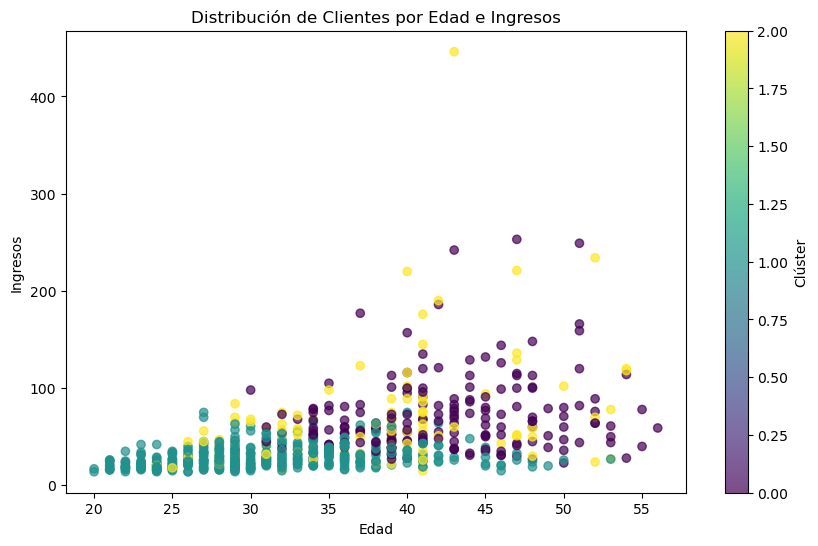

In [16]:
import matplotlib.pyplot as plt

# Configuramos el tamaño de la figura
plt.figure(figsize=(10, 6))

# Dibujamos el scatter plot usando 'Edad' e 'Ingresos'
# El parámetro 'c=df_cluster["Cluster"]' asigna el color según el grupo
plt.scatter(df_cluster['Edad'], df_cluster['Ingresos'], c=df_cluster['Cluster'], cmap='viridis', alpha=0.7)

# Añadimos etiquetas y título para mayor claridad
plt.xlabel('Edad')
plt.ylabel('Ingresos')
plt.title('Distribución de Clientes por Edad e Ingresos')
plt.colorbar(label='Clúster')

# Mostramos el gráfico
plt.show()

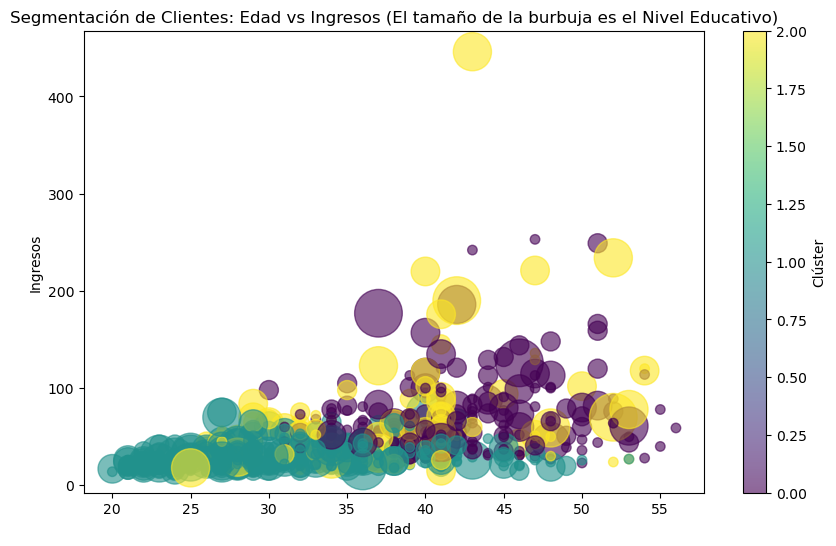

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Configuramos el tamaño de la figura
plt.figure(figsize=(10, 6))

# Calculamos el área de las burbujas usando la columna 'Nivel_Educativo'
# Multiplicamos por 15 para ajustar el tamaño visual de los círculos
area = np.pi * (df_cluster['Nivel_Educativo']) ** 2 * 15

# Creamos el gráfico de dispersión con burbujas
scatter = plt.scatter(
    df_cluster['Edad'], 
    df_cluster['Ingresos'], 
    s=area,                  # El tamaño de la burbuja representa el nivel educativo
    c=df_cluster['Cluster'], # El color representa el clúster asignado
    cmap='viridis', 
    alpha=0.6                # Transparencia para ver puntos encimados
)

# Etiquetas y formato
plt.xlabel('Edad')
plt.ylabel('Ingresos')
plt.title('Segmentación de Clientes: Edad vs Ingresos (El tamaño de la burbuja es el Nivel Educativo)')
plt.colorbar(scatter, label='Clúster')

# Mostramos el gráfico
plt.show()

¿Qué logramos con esto?
Eje X (Edad) y Eje Y (Ingresos) te muestran la base de la relación comercial.

El tamaño del círculo te dice instantáneamente si el cliente tiene un nivel educativo más alto o más bajo (círculos más grandes = mayor educación).

El color te muestra a qué clúster pertenece.

## Interpretación de la Gráfica: Distribución de Clientes por Edad e Ingresos

Este gráfico combina **cuatro dimensiones** de información en una sola visualización en 2D:
* **Eje X (Edad):** Muestra la madurez del cliente (desde los 20 hasta más de 55 años).
* **Eje Y (Ingresos):** Representa el poder adquisitivo de cada cliente.
* **Color:** Indica el clúster asignado por el modelo (según la barra lateral: 0.0 es morado, 1.0 es verde agua, y 2.0 es amarillo).
* **Tamaño de la burbuja:** Representa el nivel educativo (círculos más grandes indican mayor educación).

### Análisis detallado por Clúster:

* **Clúster 1 (Verde Agua - Abajo a la izquierda):**
  * **Ubicación:** Concentrado fuertemente en la zona inferior izquierda.
  * **Lectura:** Corresponde a personas jóvenes (20 a 35 años) con ingresos bajos (generalmente por debajo de 50). El modelo detectó con éxito que la juventud está estrechamente ligada a sueldos de entrada o menor experiencia laboral.

* **Clúster 0 (Morado - El bloque central y masivo):**
  * **Ubicación:** Ocupa la mayor parte del centro y la derecha del gráfico, abarcando edades de 35 a 55 años con ingresos moderados (entre 40 y 100).
  * **Lectura:** Representa la "columna vertebral" o núcleo de clientes maduros y financieramente estables, con trayectorias laborales constantes.

* **Clúster 2 (Amarillo - Puntos altos y dispersos):**
  * **Ubicación:** Dispersos hacia la parte superior de la gráfica (incluyendo valores atípicos con ingresos muy altos que superan los 400).
  * **Lectura:** Refleja perfiles de mayores ingresos o casos atípicos. Al observar el tamaño de las burbujas, suelen tener mayor nivel educativo; sin embargo, esto nos enseña que ganar más dinero o tener más educación no exime al cliente de pertenecer a un grupo de mayor riesgo si sus niveles de endeudamiento superan sus límites.

## Filtrar los clientes por su clúster (para campañas específicas)
Supongamos que quieres 1. Mandar una promoción de ahorro o créditos controlados al Clúster 0 (los estables), o una campaña de rescate/advertencia al Clúster 2 (los endeudados). Puedes filtrar el DataFrame con una simple línea de código:

In [18]:
# Filtrar solo los clientes del Clúster de alto riesgo (Clúster 2)
clientes_riesgo = df_cluster[df_cluster['Cluster'] == 2]

# Ver los primeros clientes de este grupo
print(f"Total de clientes en riesgo: {len(clientes_riesgo)}")
clientes_riesgo.head()

Total de clientes en riesgo: 101


,Edad,Nivel_Educativo,Años_Empleo,Ingresos,Deuda_Tarjeta,Otra_Deuda,Incumplimiento,Ratio_Deuda_Ingreso,Cluster
2,33,2,10,57,6.111,5.802,1.0,20.9,2
22,28,3,6,47,5.574,3.732,1.0,19.8,2
24,37,4,10,123,3.022,18.257,0.0,17.3,2
42,28,2,5,34,3.099,4.993,0.0,23.8,2
51,36,1,11,33,1.266,9.459,0.0,32.5,2


2. Exportar la lista con los correos (o IDs) para marketing
Si tu dataset original tiene una columna de correos electrónicos (Correo) o nombres de clientes, puedes exportar un archivo CSV exclusivo para cada campaña:

In [19]:
# Suponiendo que tu DataFrame tiene una columna llamada 'Correo' o 'ID_Cliente'
# Guardamos los clientes del Clúster 1 (jóvenes) para una promoción de tarjeta de crédito básica
clientes_jovenes = df_cluster[df_cluster['Cluster'] == 1]

# Exportar a un archivo CSV listo para importar en tu herramienta de Email Marketing (Mailchimp, HubSpot, etc.)
clientes_jovenes.to_csv('campana_clientes_jovenes.csv', index=False)

## 6. Aplicación de Negocio: Segmentación para Campañas

Ahora que nuestros clientes están etiquetados, podemos utilizarlos para tomar decisiones estratégicas:
1. **Cuantificar los segmentos:** Ver cuántos clientes tenemos en cada clúster para dimensionar el impacto de una campaña.
2. **Filtrar por grupo:** Aislar a un segmento específico (por ejemplo, los de alto riesgo o los jóvenes).
3. **Exportar bases de datos:** Generar archivos CSV separados para integrarlos en herramientas de Email Marketing o CRM.

In [21]:
# 1. Contar cuántos clientes pertenecen a cada clúster
conteo_clusters = df_cluster['Cluster'].value_counts().sort_index()
print("--- Cantidad de clientes por Clúster ---")
print(conteo_clusters)
print("\n" + "="*40 + "\n")

# 2. Filtrar cada segmento para su respectiva campaña comercial
clientes_fieles = df_cluster[df_cluster['Cluster'] == 0]
clientes_jovenes = df_cluster[df_cluster['Cluster'] == 1]
clientes_riesgo = df_cluster[df_cluster['Cluster'] == 2]

print(f"Clientes estables (Clúster 0): {len(clientes_fieles)}")
print(f"Clientes jóvenes (Clúster 1): {len(clientes_jovenes)}")
print(f"Clientes en riesgo (Clúster 2): {len(clientes_riesgo)}")

# 3. Exportar los tres segmentos a archivos CSV independientes
clientes_fieles.to_csv('clientes_fieles_cluster0.csv', index=False)
clientes_jovenes.to_csv('clientes_jovenes_cluster1.csv', index=False)
clientes_riesgo.to_csv('clientes_riesgo_cluster2.csv', index=False)

print("\n¡Los tres archivos CSV se han exportado con éxito para las campañas comerciales!")

--- Cantidad de clientes por Clúster ---
Cluster
0    187
1    412
2    101
Name: count, dtype: int64


Clientes estables (Clúster 0): 187
Clientes jóvenes (Clúster 1): 412
Clientes en riesgo (Clúster 2): 101

¡Los tres archivos CSV se han exportado con éxito para las campañas comerciales!


<h2>El Flujo Maestro de Segmentación (K-Means)</h2>
Preparación y Limpieza de Datos: Cargar tu dataset, eliminar columnas irrepetibles o IDs, y manejar valores nulos si los hay.

Escalado de Datos (StandardScaler): Fundamental para que todas las variables tengan el mismo peso y el algoritmo no se confunda si unas están en miles y otras en unidades pequeñas.

Entrenamiento del Modelo (KMeans): Definir el número de clústeres (por ejemplo, con el método del codo) y entrenar el algoritmo (fit_predict).

Análisis de Centroides: Sacar los valores promedio por clúster (groupby) para entender matemáticamente qué representa cada grupo.

Interpretación y Perfilado: Traducir esos números fríos en perfiles de negocio (ej. jóvenes, estables, de riesgo).

Visualización Avanzada: Usar gráficos (como el de dispersión con burbujas) para comprobar que los grupos tienen sentido lógico en el plano.

Acción Comercial (Exportación): Filtrar los DataFrames y exportar CSVs individuales para estrategias de marketing, CRM o retención.

Siempre que te enfrentes a un problema donde necesites agrupar elementos por similitud sin etiquetas previas (aprendizaje no supervisado), puedes seguir exactamente esta misma ruta crítica.